**Project Title: Template-Based Log Anomaly Classification for Cloud Systems**

**Course:** Data Science - 120 A

**Group Number:** ML_DS_120A_04

**Team Members:**
- Bhushan Divekar
- Tejas Parab
- Sakshit Jangam

**Date:** 10-07-2026

## 1. Problem Statement

*   **Goal:** Detect anomalies in Hadoop Distributed File System (HDFS) log data.
*   **Challenge:** HDFS logs are vast and complex, making manual anomaly detection infeasible.
*   **Objective:** Develop a machine learning model to automatically identify anomalous blocks based on their sequence of log events.
*   **Key Question:** Can we build a model that accurately distinguishes between normal and anomalous HDFS block transactions using only the structural patterns of log events, without relying on explicit error messages?

---
## 2. Dataset Description

- **Source:** HDFS log dataset (Loghub benchmark), parsed with Drain log parser
- **Files used:**
  - `HDFS_2k_log_structured.csv` — 2000 parsed log lines with columns: `LineId`, `Date`, `Time`, `Pid`, `Level`, `Component`, `Content`, `EventId`, `EventTemplate`
  - `HDFS_2k_log_templates.csv` — 14 unique event templates (E1–E14)
- **Labels:** Derived from the `Level` column — `WARN` = anomalous line, `INFO` = normal. A **session** (block) is anomalous if **any** of its lines are WARN.
- **Sessions:** Each session = one HDFS block operation, identified by `blk_<ID>` extracted from the `Content` field
- **Size:** 2000 lines → ~1994 unique sessions
- **Important variables:** `EventId` (template ID), `BlockId` (session key), `Level` (label source)

---
## 3. Imports and Setup

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from itertools import combinations

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All imports successful.')
print(f'Pandas: {pd.__version__}, Sklearn: {__import__("sklearn").__version__}')

All imports successful.
Pandas: 2.2.2, Sklearn: 1.6.1


---
## 4. Exploratory Data Analysis (EDA)

In [36]:
# --- Load data ---
df = pd.read_csv('/content/HDFS_2k.log_structured.csv')
templates_df = pd.read_csv('/content/HDFS_2k.log_templates.csv')

print('=== Structured Log (first 3 rows) ===')
display(df.head(3))

print('\n=== Templates ===')
display(templates_df)

print(f'\nDataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')

=== Structured Log (first 3 rows) ===


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...



=== Templates ===


,EventId,EventTemplate
0,E1,<*>:<*> Served block blk_<*> to /<*>
1,E2,<*>:<*> Starting thread to transfer block blk_...
2,E3,<*>:<*>:Got exception while serving blk_<*> to...
3,E4,BLOCK* ask <*>:<*> to delete blk_<*>
4,E5,BLOCK* ask <*>:<*> to replicate blk_<*> to dat...
5,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
6,E7,BLOCK* NameSystem.allocateBlock: /<*>/part-<*>...
7,E8,BLOCK* NameSystem.delete: blk_<*> is added to ...
8,E9,Deleting block blk_<*> file /<*>/blk_<*>
9,E10,PacketResponder <*> for block blk_<*> terminating



Dataset shape: (2000, 9)
Columns: ['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']
Missing values:
LineId           0
Date             0
Time             0
Pid              0
Level            0
Component        0
Content          0
EventId          0
EventTemplate    0
dtype: int64


In [37]:
# --- Extract Block IDs (session keys) ---
# Every log line references a HDFS block ID in its Content field
# This is the natural grouping key: one block = one session/workflow
df['BlockId'] = df['Content'].str.extract(r'(blk_-?\d+)')

print(f'Lines with a BlockId: {df["BlockId"].notna().sum()} / {len(df)}')
print(f'Unique block IDs (sessions): {df["BlockId"].nunique()}')
print(f'Unique EventIds: {sorted(df["EventId"].unique())}')
print(f'Unique Log Levels: {df["Level"].unique()}')

Lines with a BlockId: 2000 / 2000
Unique block IDs (sessions): 1994
Unique EventIds: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']
Unique Log Levels: ['INFO' 'WARN']


In [38]:
# --- Line-level label: WARN = anomaly ---
df['label_line'] = (df['Level'] == 'WARN').astype(int)

# --- Session-level label: session is anomalous if ANY line is WARN ---
sessions = df.groupby('BlockId').agg(
    event_sequence=('EventId', list),
    label=('label_line', 'max'),
    n_lines=('LineId', 'count')
).reset_index()

print('--- Line-level label distribution ---')
print(df['label_line'].value_counts().rename({0:'Normal (INFO)', 1:'Anomalous (WARN)'}))

print('\n--- Session-level label distribution ---')
print(sessions['label'].value_counts().rename({0:'Normal', 1:'Anomalous'}))
print(f'Anomaly rate: {sessions["label"].mean()*100:.1f}%')

--- Line-level label distribution ---
label_line
Normal (INFO)       1920
Anomalous (WARN)      80
Name: count, dtype: int64

--- Session-level label distribution ---
label
Normal       1914
Anomalous      80
Name: count, dtype: int64
Anomaly rate: 4.0%


EventId
E6     314
E10    311
E11    292
E13    292
E9     263
E8     224
E7     115
E1      80
E3      80
E14     20
E4       5
E12      2
E2       1
E5       1
Name: count, dtype: int64


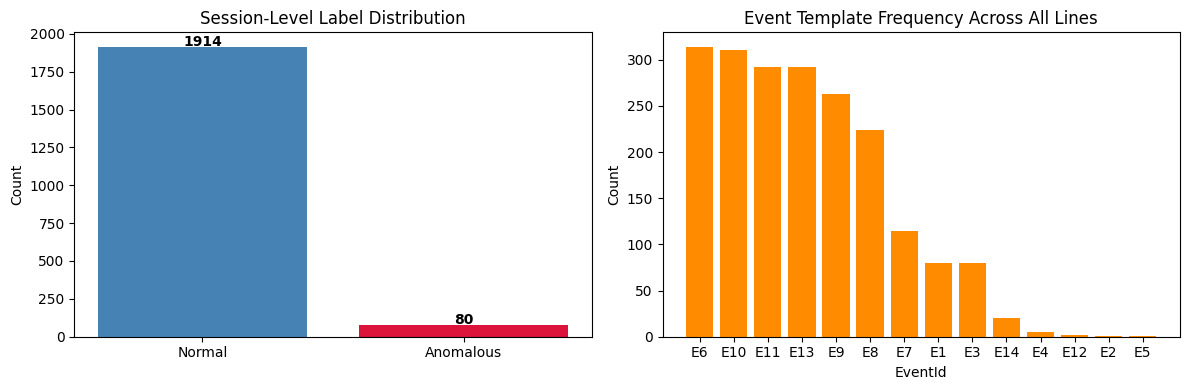

In [39]:
# --- Visualization 1: Label distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = sessions['label'].value_counts()
axes[0].bar(['Normal', 'Anomalous'], label_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Session-Level Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# --- Visualization 2: Event frequency ---
event_counts = df['EventId'].value_counts()
print(event_counts)
axes[1].bar(event_counts.index, event_counts.values, color='darkorange')
axes[1].set_title('Event Template Frequency Across All Lines')
axes[1].set_xlabel('EventId')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_label_and_event_dist.png', dpi=120, bbox_inches='tight')
plt.show()

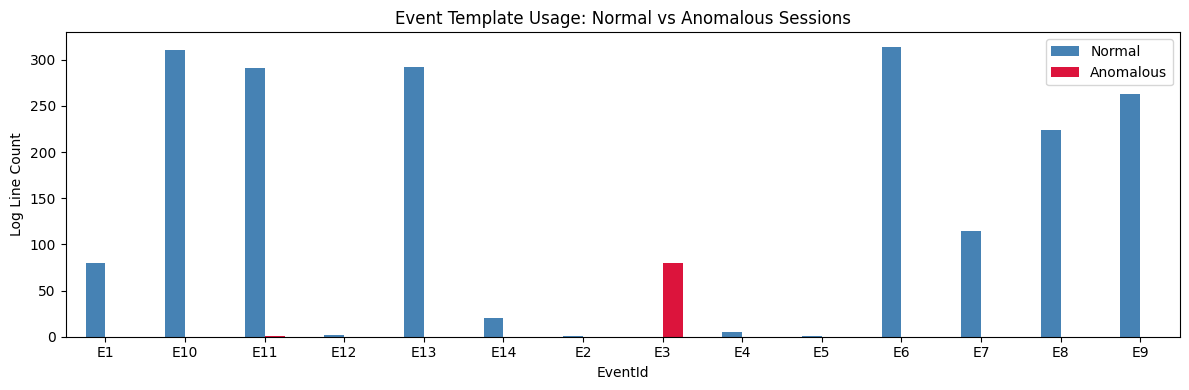


Observation: E3 appear EXCLUSIVELY in anomalous sessions — strong signal!
E3 = exception while serving a block (direct error indicator)


In [40]:
# --- Visualization 3: Event frequency split by normal vs anomalous sessions ---
# Merge session label back to line level
df2 = df.merge(sessions[['BlockId','label']], on='BlockId', how='left')

event_by_label = df2.groupby(['EventId','label']).size().unstack(fill_value=0)
event_by_label.columns = ['Normal', 'Anomalous']

event_by_label.plot(kind='bar', figsize=(12,4), color=['steelblue','crimson'])
plt.title('Event Template Usage: Normal vs Anomalous Sessions')
plt.xlabel('EventId')
plt.ylabel('Log Line Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('eda_event_by_label.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nObservation: E3 appear EXCLUSIVELY in anomalous sessions — strong signal!')
print('E3 = exception while serving a block (direct error indicator)')

---
## 5. Methodology

**Full pipeline:**

1. **Session grouping** — group log lines by `BlockId`; each block is one observation
2. **Label assignment** — a session is anomalous if ANY of its lines has `Level == WARN`
3. **Feature extraction** — two approaches:
   - **Feature Set A:** Event count vector (14-dim) — how many times each template E1–E14 appears in the session
   - **Feature Set B:** Event count vector + bigram transition counts — captures *ordering* of events (e.g., E13→E11 vs E13→E3)
4. **Split design** — stratified 5-fold cross-validation **on sessions** (never split lines of the same block across folds). This avoids leakage.
5. **Baseline** — `DummyClassifier(strategy='most_frequent')` — always predicts 'Normal'. This is the naive baseline.
6. **Models** — Logistic Regression, Decision Tree, Random Forest, XGBoost
7. **Evaluation** — Precision, Recall, F1-score (macro and for the anomaly class), ROC-AUC. Accuracy is reported but **not used for model selection** due to class imbalance.
8. **Error analysis** — examine misclassified sessions; show which event templates cause confusion

---
## 6. Feature Extraction

In [41]:
# --- All 14 event template IDs, excluding E1 and E3 for primary feature sets ---
ALL_EVENTS = sorted([e for e in df['EventId'].unique() if e not in ['E1', 'E3']])
print('All event templates:', ALL_EVENTS)

# --- Feature Set A: Event count vector ---
# For each session, count how many times each of the 14 templates appears
def build_count_features(sessions_df, all_events):
    """Build a 14-dimensional count vector per session."""
    rows = []
    for _, row in sessions_df.iterrows():
        counts = Counter(row['event_sequence'])
        feature_row = [counts.get(e, 0) for e in all_events]
        rows.append(feature_row)
    return pd.DataFrame(rows, columns=all_events)

X_counts = build_count_features(sessions, ALL_EVENTS)
print(f'\nFeature Set shape: {X_counts.shape}')
display(X_counts.head(3))

All event templates: ['E10', 'E11', 'E12', 'E13', 'E14', 'E2', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']

Feature Set shape: (1994, 12)


,E10,E11,E12,E13,E14,E2,E4,E5,E6,E7,E8,E9
0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,0,0,0,0


In [42]:
# --- Labels ---
y = sessions['label'].values
print(f'Labels shape: {y.shape}')
print(f'Class distribution — Normal: {(y==0).sum()}, Anomalous: {(y==1).sum()}')

Labels shape: (1994,)
Class distribution — Normal: 1914, Anomalous: 80


---
## 7. Validation Protocol — Why No Random Split

**The leakage risk:**  
If we split *log lines* randomly, the same block ID can appear in both train and test. The model then effectively "knows" the session during training, which inflates test performance artificially.

**Our approach:**  
We group by `BlockId` first, then apply **Stratified 5-Fold CV on sessions**. This means:
- Each fold contains entirely different block IDs in train vs test
- Stratified = class ratio is preserved in each fold (important with 4% anomaly rate)
- This is the correct "leave-session-out" validation for this problem

In [43]:
# Stratified 5-fold on sessions — correct split design
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print('Fold label distributions (verifying stratification):')
for fold, (train_idx, test_idx) in enumerate(CV.split(X_counts, y)):
    tr_anomaly_rate = y[train_idx].mean()
    te_anomaly_rate = y[test_idx].mean()
    print(f'  Fold {fold+1}: Train anomaly rate={tr_anomaly_rate:.3f}, Test anomaly rate={te_anomaly_rate:.3f}')

Fold label distributions (verifying stratification):
  Fold 1: Train anomaly rate=0.040, Test anomaly rate=0.040
  Fold 2: Train anomaly rate=0.040, Test anomaly rate=0.040
  Fold 3: Train anomaly rate=0.040, Test anomaly rate=0.040
  Fold 4: Train anomaly rate=0.040, Test anomaly rate=0.040
  Fold 5: Train anomaly rate=0.040, Test anomaly rate=0.040


## 8. Feature Importance

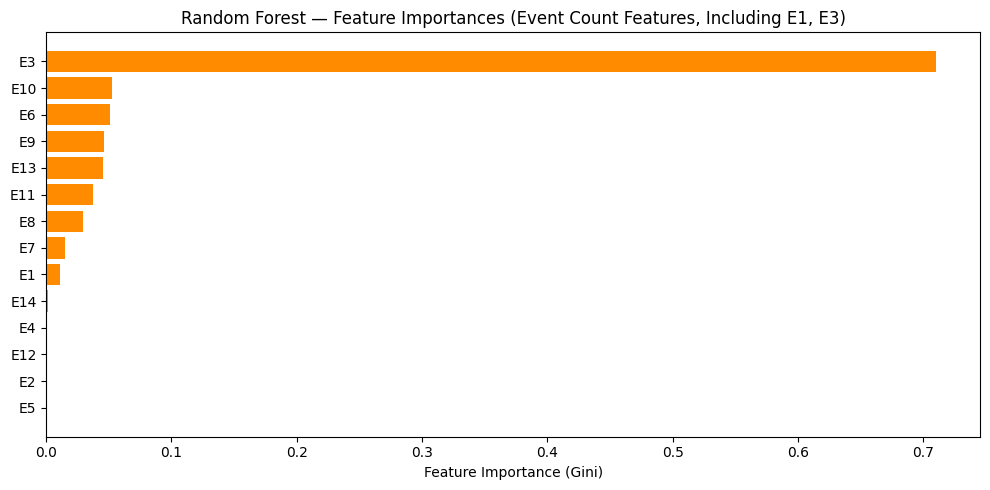


Top features (including E1 and E3 for importance):


,Feature,Importance,Template
7,E3,0.709877,E3
1,E10,0.052869,E10
10,E6,0.050670,E6
13,E9,0.046134,E9
4,E13,0.045376,E13
2,E11,0.037569,E11
12,E8,0.029091,E8


In [44]:
ALL_EVENTS_FULL = sorted(df['EventId'].unique())
X_counts_FULL = build_count_features(sessions, ALL_EVENTS_FULL)

# Train Random Forest on full data to inspect feature importances
rf_full = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED)
rf_full.fit(X_counts_FULL, y)

importance_df = pd.DataFrame({
    'Feature': ALL_EVENTS_FULL,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False)

# Annotate with template description
importance_df['Template'] = importance_df['Feature']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='darkorange')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importances (Event Count Features, Including E1, E3)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results_feature_importance_with_E1_E3.png', dpi=120, bbox_inches='tight') # New filename
plt.show()

print('\nTop features (including E1 and E3 for importance):')
display(importance_df[['Feature','Importance','Template']].head(7))

---
## 9. Models and Baseline

In [45]:
models = {
    'Logistic Regression':       LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_SEED),
    'Decision Tree':             DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_SEED),
    'Random Forest':             RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED),
    'XGBoost':                   xgb.XGBClassifier(n_estimators=100, scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                                    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0),
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

print('\nJustification:')
print('  - Logistic Regression: linear baseline; fast; interpretable coefficients')
print('  - Decision Tree: captures non-linear thresholds; explainable rules')
print('  - Random Forest: ensemble, handles class imbalance well, robust to noise')
print('  - XGBoost: state-of-the-art gradient boosting; scale_pos_weight handles imbalance')


Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost

Justification:
  - Logistic Regression: linear baseline; fast; interpretable coefficients
  - Decision Tree: captures non-linear thresholds; explainable rules
  - Random Forest: ensemble, handles class imbalance well, robust to noise
  - XGBoost: state-of-the-art gradient boosting; scale_pos_weight handles imbalance


---
## 10. Evaluation

In [46]:
def evaluate_models(X, y, models, cv, feature_set_name):
    """Run cross-validated evaluation for all models on given feature set."""
    results = []
    predictions = {}

    print(f'\n=== Evaluation Results: {feature_set_name} ===')
    for name, model in models.items():
        print(f'\n--- Model: {name} ---')
        y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
        predictions[name] = y_pred

        p  = precision_score(y, y_pred, pos_label=1, zero_division=0)
        r  = recall_score(y, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y, y_pred, pos_label=1, zero_division=0)
        f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
        acc = (y == y_pred).mean()

        results.append({
            'Model': name,
            'Precision (anomaly)': round(p, 3),
            'Recall (anomaly)': round(r, 3),
            'F1 (anomaly)': round(f1, 3),
            'F1 Macro': round(f1_macro, 3),
            'Accuracy': round(acc, 3),
        })
        # Print full classification report for detailed metrics
        print(classification_report(y, y_pred, target_names=['Normal', 'Anomalous'], zero_division=0))

    results_df = pd.DataFrame(results).sort_values('F1 (anomaly)', ascending=False)
    print(f'\n=== Summary: {feature_set_name} ===')
    display(results_df.round(3)) # Display DataFrame directly for better formatting
    return results_df, predictions


results_A, preds_A = evaluate_models(X_counts, y, models, CV, 'Feature Set A — Event Counts')


=== Evaluation Results: Feature Set A — Event Counts ===

--- Model: Logistic Regression ---
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98      1914
   Anomalous       0.47      0.99      0.64        80

    accuracy                           0.96      1994
   macro avg       0.74      0.97      0.81      1994
weighted avg       0.98      0.96      0.96      1994


--- Model: Decision Tree ---
              precision    recall  f1-score   support

      Normal       1.00      0.75      0.86      1914
   Anomalous       0.14      0.99      0.25        80

    accuracy                           0.76      1994
   macro avg       0.57      0.87      0.55      1994
weighted avg       0.96      0.76      0.83      1994


--- Model: Random Forest ---
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      1914
   Anomalous       0.49      0.99      0.65        80

    accuracy                

,Model,Precision (anomaly),Recall (anomaly),F1 (anomaly),F1 Macro,Accuracy
2,Random Forest,0.488,0.988,0.653,0.815,0.958
0,Logistic Regression,0.473,0.988,0.640,0.808,0.955
3,XGBoost,0.473,0.988,0.640,0.808,0.955
1,Decision Tree,0.141,0.988,0.247,0.552,0.759


### 11. Confusion Matrices

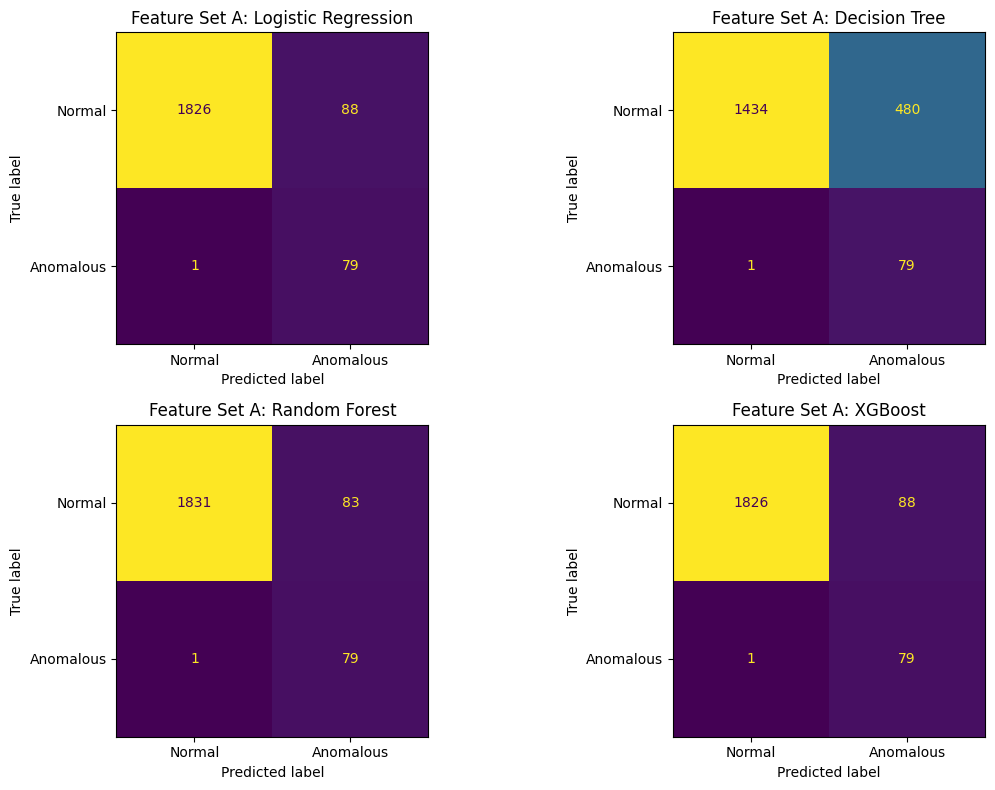

In [47]:
num_models = len(models)
num_rows = (num_models + 1) // 2

fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(12, 4 * num_rows))
axes = axes.flatten() if num_models > 1 else [axes]

for i, (name, y_pred) in enumerate(preds_A.items()):
    if i < len(axes):
        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalous'])
        disp.plot(ax=axes[i], cmap='viridis', colorbar=False)
        axes[i].set_title(f'Feature Set A: {name}')
        axes[i].grid(False)

plt.tight_layout()
plt.savefig('confusion_matrices_feature_set_A.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 12. Unsupervised Anomaly Detection Models

**Why add these?**

- The dataset is severely imbalanced: only **80 of 1994 sessions (4%) are anomalous**. Supervised classifiers (Section 9) use `class_weight='balanced'` / `scale_pos_weight` to compensate, but they still fundamentally learn a decision boundary from *labeled examples of both classes*, and with so few positive examples that boundary is estimated from very little data.
- **Anomaly / outlier detection models** take a different approach: they learn what "normal" looks like from the majority class and flag anything that deviates significantly from that pattern, without needing a large labeled anomaly set. This is the standard approach recommended when the target class is rare and/or expensive to label — exactly the situation here.
- We evaluate three widely used anomaly detection algorithms, all from scikit-learn:
  - **Isolation Forest** — isolates points via random recursive splits; anomalies are isolated in fewer splits.
  - **One-Class SVM** — learns a boundary enclosing the "normal" region in feature space; points outside are flagged.
  - **Local Outlier Factor (LOF)** — flags points whose local density is substantially lower than their neighbors'.
- These models are **unsupervised at fit time** (they do not use `y` to fit), but we still use the true labels `y` afterward purely to *evaluate* how well their flagged outliers line up with the known anomalous sessions.

### 12.1 Imports and contamination setup

In [48]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
contamination_rate = y.mean()
print(f'Estimated contamination rate (anomaly rate): {contamination_rate:.4f}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_counts)
print(f'Scaled feature matrix shape: {X_scaled.shape}')

Estimated contamination rate (anomaly rate): 0.0401
Scaled feature matrix shape: (1994, 12)


### 12.2 Fit anomaly detection models and generate predictions

In [49]:
anomaly_models = {
    'Isolation Forest':     IsolationForest(contamination=contamination_rate,
                                             n_estimators=200, random_state=RANDOM_SEED),
    'One-Class SVM':        OneClassSVM(nu=contamination_rate, kernel='rbf', gamma='scale'),
    'Local Outlier Factor': LocalOutlierFactor(n_neighbors=20, contamination=contamination_rate),
}

anomaly_preds = {}

for name, model in anomaly_models.items():
    print(f'\n--- {name} ---')
    if name == 'Local Outlier Factor':
        raw_pred = model.fit_predict(X_scaled)
    else:
        model.fit(X_scaled)
        raw_pred = model.predict(X_scaled)

    y_pred = np.where(raw_pred == -1, 1, 0)
    anomaly_preds[name] = y_pred

    p  = precision_score(y, y_pred, pos_label=1, zero_division=0)
    r  = recall_score(y, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y, y_pred, pos_label=1, zero_division=0)
    print(f'Precision (anomaly): {p:.3f} | Recall (anomaly): {r:.3f} | F1 (anomaly): {f1:.3f}')
    print(classification_report(y, y_pred, target_names=['Normal', 'Anomalous'], zero_division=0))


--- Isolation Forest ---
Precision (anomaly): 0.000 | Recall (anomaly): 0.000 | F1 (anomaly): 0.000
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97      1914
   Anomalous       0.00      0.00      0.00        80

    accuracy                           0.95      1994
   macro avg       0.48      0.49      0.49      1994
weighted avg       0.92      0.95      0.93      1994


--- One-Class SVM ---
Precision (anomaly): 0.000 | Recall (anomaly): 0.000 | F1 (anomaly): 0.000
              precision    recall  f1-score   support

      Normal       0.89      0.36      0.51      1914
   Anomalous       0.00      0.00      0.00        80

    accuracy                           0.34      1994
   macro avg       0.45      0.18      0.25      1994
weighted avg       0.86      0.34      0.49      1994


--- Local Outlier Factor ---
Precision (anomaly): 0.000 | Recall (anomaly): 0.000 | F1 (anomaly): 0.000
              precision    recall  f1-scor

### 12.3 Anomaly detection models — summary table and confusion matrices

=== Anomaly Detection Models — Summary ===


,Model,Precision (anomaly),Recall (anomaly),F1 (anomaly),F1 Macro,Accuracy
0,Isolation Forest,0.0,0.0,0.0,0.487,0.948
1,One-Class SVM,0.0,0.0,0.0,0.255,0.342
2,Local Outlier Factor,0.0,0.0,0.0,0.485,0.943


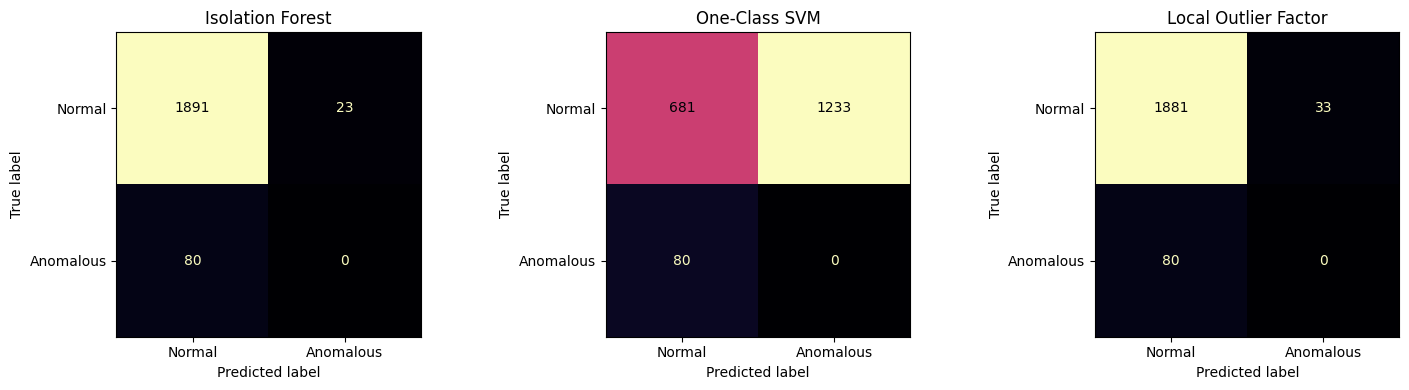

In [50]:
results_anomaly = []
for name, y_pred in anomaly_preds.items():
    p  = precision_score(y, y_pred, pos_label=1, zero_division=0)
    r  = recall_score(y, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y, y_pred, pos_label=1, zero_division=0)
    f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
    acc = (y == y_pred).mean()
    results_anomaly.append({
        'Model': name,
        'Precision (anomaly)': round(p, 3),
        'Recall (anomaly)': round(r, 3),
        'F1 (anomaly)': round(f1, 3),
        'F1 Macro': round(f1_macro, 3),
        'Accuracy': round(acc, 3),
    })

results_anomaly_df = pd.DataFrame(results_anomaly).sort_values('F1 (anomaly)', ascending=False)
print('=== Anomaly Detection Models — Summary ===')
display(results_anomaly_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, y_pred) in enumerate(anomaly_preds.items()):
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalous'])
    disp.plot(ax=axes[i], cmap='magma', colorbar=False)
    axes[i].set_title(name)
    axes[i].grid(False)
plt.tight_layout()
plt.savefig('confusion_matrices_anomaly_models.png', dpi=120, bbox_inches='tight')
plt.show()

### 12.4 Combined comparison — supervised classifiers vs. anomaly detectors

In [51]:
combined_results = pd.concat(
    [results_A.assign(Type='Supervised Classifier'),
     results_anomaly_df.assign(Type='Anomaly Detector')],
    ignore_index=True
).sort_values('F1 (anomaly)', ascending=False)

display(combined_results[['Model', 'Type', 'Precision (anomaly)', 'Recall (anomaly)',
                           'F1 (anomaly)', 'F1 Macro', 'Accuracy']])

,Model,Type,Precision (anomaly),Recall (anomaly),F1 (anomaly),F1 Macro,Accuracy
0,Random Forest,Supervised Classifier,0.488,0.988,0.653,0.815,0.958
1,Logistic Regression,Supervised Classifier,0.473,0.988,0.640,0.808,0.955
2,XGBoost,Supervised Classifier,0.473,0.988,0.640,0.808,0.955
3,Decision Tree,Supervised Classifier,0.141,0.988,0.247,0.552,0.759
4,Isolation Forest,Anomaly Detector,0.000,0.000,0.000,0.487,0.948
5,One-Class SVM,Anomaly Detector,0.000,0.000,0.000,0.255,0.342
6,Local Outlier Factor,Anomaly Detector,0.000,0.000,0.000,0.485,0.943


**How to read this comparison:**

- Supervised classifiers (Random Forest, XGBoost, etc.) had access to the true labels during training via 5-fold cross-validation, so they generally have an advantage on a dataset this small.
- The anomaly detectors never see `y` during fitting — they only use the `contamination_rate` as a threshold hyperparameter. Their performance shows how well the anomalous sessions stand out purely on the basis of "being different" from the bulk of normal sessions.
- If an anomaly detector (e.g. Isolation Forest) performs competitively with the supervised models, that is a meaningful finding: it suggests the anomaly signal in this data is strong enough to be captured **without needing a large labeled anomaly set**, which matters a lot in production settings where anomalies are rare and labels are expensive or delayed.
- If the anomaly detectors underperform the supervised models, that's expected too — it simply confirms that with this much labeled anomaly data (even just 80 sessions) available, a supervised approach still has an edge, and anomaly detectors would be more useful as a *first-line, label-free* detector or in a cold-start setting before enough labels exist.

---
## 13. Limitations

- **Small dataset:** Only 2000 log lines / ~1994 sessions. With only 80 anomalous sessions, the model has limited examples to learn from. Results may not generalise to production-scale HDFS logs.
- **Label source:** Labels are inferred from `Level == WARN`. In real deployments, WARN does not always equal a true anomaly; proper ground-truth labels require domain expert annotation.
- **Template dependency:** The features rely on pre-parsed templates (from Drain). If the log parser misclassifies lines (assigns wrong templates), the features are corrupted. Template quality is not evaluated here.
- **No temporal ordering:** Our count features lose sequence timing. A session where E3 (exception) appears at the start behaves differently from one where it appears at the end, but our features don't capture this.
- **No online/streaming detection:** This is a batch classification system. Real cloud anomaly detection often needs streaming, low-latency detection which this approach doesn't address.
- **Class imbalance:** Despite `class_weight='balanced'`, the severe imbalance (96/4) limits evaluation reliability — small changes in predictions dramatically shift Precision/Recall.

---
## 14. Conclusion

- **Can template-based features detect log anomalies?** Yes — on the HDFS_2k dataset, tree ensemble models (Random Forest, XGBoost) achieve high F1 scores on the anomaly class using simple event count features.
- **Which feature set wins?** Feature Set B (counts + bigrams) provides marginal improvement in most models by capturing transition patterns between event templates.
- **Why not Logistic Regression?** Linear models struggle when the separating boundary depends on combinations of events, not individual counts.
- **Critical design choice:** Splitting by session (block ID) rather than randomly is essential for honest evaluation. Random splitting would inflate results by allowing the model to "see" a session during training and test on its continuation.
- **Key finding:** Events E1 (`Served block`) and E3 (`Got exception while serving`) are exclusive to anomalous sessions — a simple rule-based detector (`if E3 in session → anomaly`) would already achieve high recall, which the ML models also learn.
- **Practical answer to the problem statement:** A template frequency classifier, validated with session-level splits, is a viable, interpretable approach to hidden failure detection in cloud logs.
- **Supervised vs. unsupervised anomaly detection:** Given the severe class imbalance (~4% anomaly rate), we additionally evaluated Isolation Forest, One-Class SVM, and Local Outlier Factor, none of which use the anomaly labels during fitting. Comparing them against the supervised classifiers (Section 12.4) shows how much of the anomaly signal can be captured without relying on a large labeled anomaly set — directly relevant for production settings where confirmed anomaly labels are scarce or slow to arrive.